## 03 — Merge FFPE and snRNA-seq Datasets

**Purpose:** Integrate the two preprocessed datasets (FFPE scRNA-seq + snRNA-seq) via Harmony on the intersection of variable genes. Performs joint clustering to 18 clusters, annotates them to 12 consensus cell types, and exports harmonized labels for downstream notebooks.

**Inputs:**
- `_data/obj_27448cells_labeled_v2.rds` — FFPE object (from `01_Seurat_ffpe.ipynb`)
- `_data/snRNAseq/obj_43854cells_labeled_v2.rds` — snRNA-seq object (from `01_Seurat_nuc-seq.ipynb`)

**Outputs:**
- `_data/obj_merged_71302cells_labeled.rds` — merged Seurat object (71,302 cells)
- `_data/obj_merged_scRNA_labels.csv` — cell type + UMAP labels for FFPE cells
- `_data/obj_merged_snRNA_labels.csv` — cell type + UMAP labels for snRNA-seq cells

**Run after:** `01_Seurat_ffpe.ipynb`, `01_Seurat_nuc-seq.ipynb`

# Merge scRNA-seq and snRNA-seq

In [1]:
set.seed(1)
source('./utils.R')
#devtools::install_github("pati-ni/harmony", ref="lapack-win-fix", force=TRUE)

# Standard pipeline

## Load datasets

**Load sample info for treated lesions (FFPE)**

In [2]:
obj_sc = readRDS('../_data/ffpe/obj_27448cells_labeled_v2.rds')

**Load sample info for untreated lesions (OCT)**

In [3]:
obj_sn = readRDS('../_data/snRNAseq/obj_43854cells_labeled_v2.rds') 

**Merge on shared genes**

In [4]:
genes1 = rownames(obj_sc)
genes2 = rownames(obj_sn)
common_genes = intersect(genes1, genes2)
message("Number of genes in object 1: ", length(genes1))
message("Number of genes in object 2: ", length(genes2))
message("Number of common genes: ", length(common_genes))

# Select top 2000 variable genes per dataset
obj_sc = subset(obj_sc, features = common_genes) %>% 
        FindVariableFeatures(selection.method = "vst", nfeatures = 2000)
obj_sn = subset(obj_sn, features = common_genes) %>% 
        FindVariableFeatures(selection.method = "vst", nfeatures = 2000)

obj_merged = merge(obj_sc, obj_sn, add.cell.ids = c("sc", "sn"), project = "merged")
obj_merged

# Select the union of variable genes in each dataset
vargenes_sc = VariableFeatures(obj_sc)
vargenes_sn = VariableFeatures(obj_sn)
vargenes = intersect(common_genes, union(vargenes_sc, vargenes_sn))

message("Number of vargenes in object 1: ", length(vargenes_sc))
message("Number of vargenes in object 2: ", length(vargenes_sn))
message("Number of common genes: ", length(vargenes))

# Exclude cell cycle and MT and ribosome genes
mt_ri = grep("^MT-|^RPL|^RPS|MALAT1|MIR-", rownames(obj_merged), value = TRUE)
cycle_prolif = c(Seurat::cc.genes$s.genes, Seurat::cc.genes$g2m.genes)
genes_exclude = union(mt_ri, cycle_prolif)
vargenes = vargenes[-which(vargenes %in% genes_exclude)]
message("Number of variable genes after exclusions: ", length(vargenes))

Number of genes in object 1: 16870

Number of genes in object 2: 31161

Number of common genes: 16399

Finding variable features for layer counts

Finding variable features for layer counts



An object of class Seurat 
16399 features across 71302 samples within 1 assay 
Active assay: RNA (16399 features, 2000 variable features)
 6 layers present: counts.ffpe, counts.nuc-seq, data.ffpe, scale.data.ffpe, data.nuc-seq, scale.data.nuc-seq

Number of vargenes in object 1: 2000

Number of vargenes in object 2: 2000

Number of common genes: 3148

Number of variable genes after exclusions: 3097



## Normalization and PCA

In [5]:
# clean up space in memory
rm(obj_sc)
rm(obj_sn)

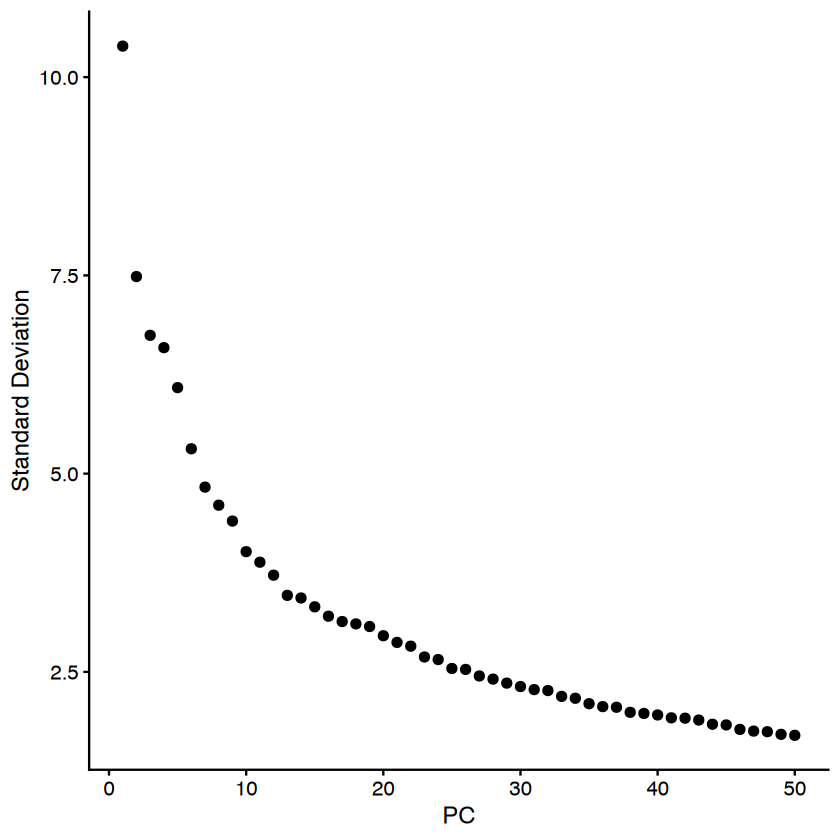

In [6]:
.verbose = FALSE
# Data already per-cell normalized
obj = obj_merged %>% ScaleData(features = rownames(obj_merged), verbose = .verbose) %>%
                RunPCA(features = vargenes, verbose = .verbose)
obj@meta.data$dataset = ifelse(obj@meta.data$dataset == 'ffpe', 'scRNA-seq', 'snRNA-seq')
ElbowPlot(obj, ndims = 50, reduction = "pca") # Elbow plot

In [7]:
rm(obj_merged)

Pre-harmony PCA

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


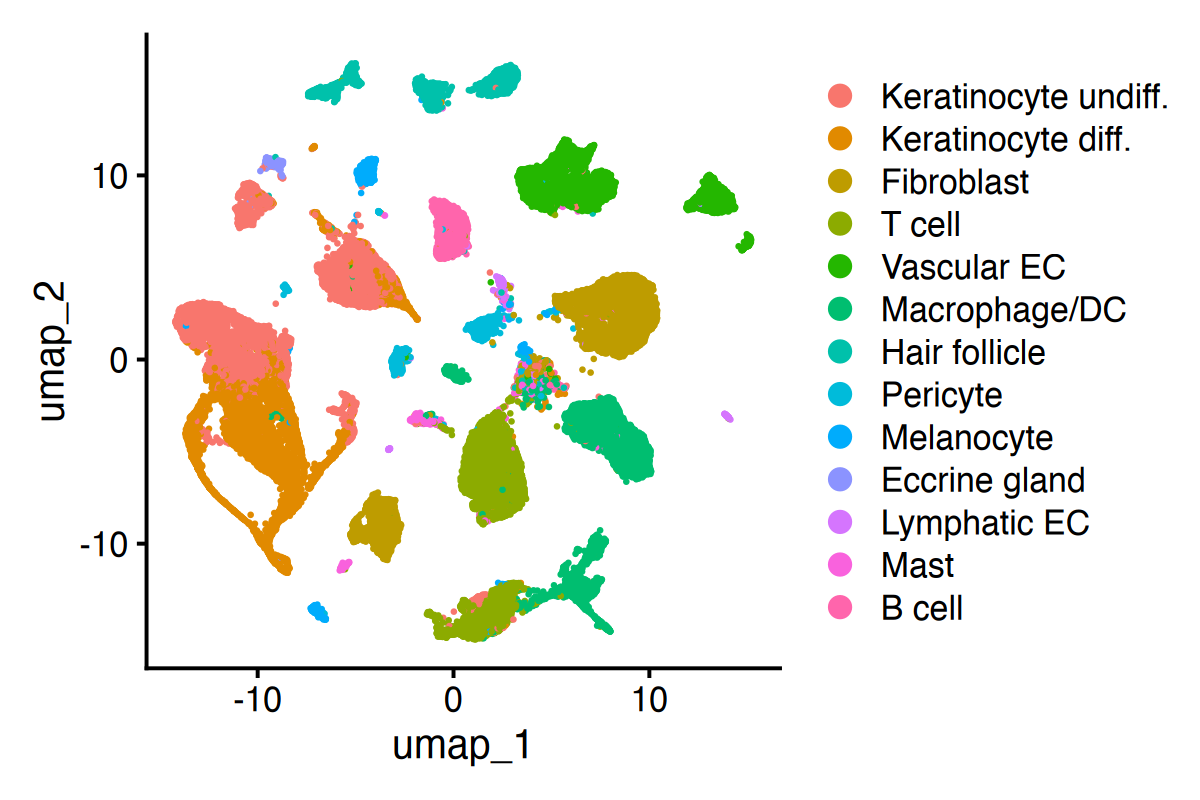

In [8]:
obj = obj %>% RunUMAP(dims = 1:30, verbose = .verbose)

fig.size(4, 6)
DimPlot(obj, reduction = "umap", shuffle = TRUE)

## Harmony

Transposing data matrix

Using automatic lambda estimation

Thetas: 1

Initializing state using k-means centroids initialization



Initializing centroids


Harmony 1/20

Harmony 2/20

Harmony 3/20

Harmony 4/20

Harmony 5/20

Harmony 6/20

Harmony 7/20

Harmony 8/20

Harmony 9/20

Harmony 10/20

Harmony 11/20

Harmony converged after 11 iterations



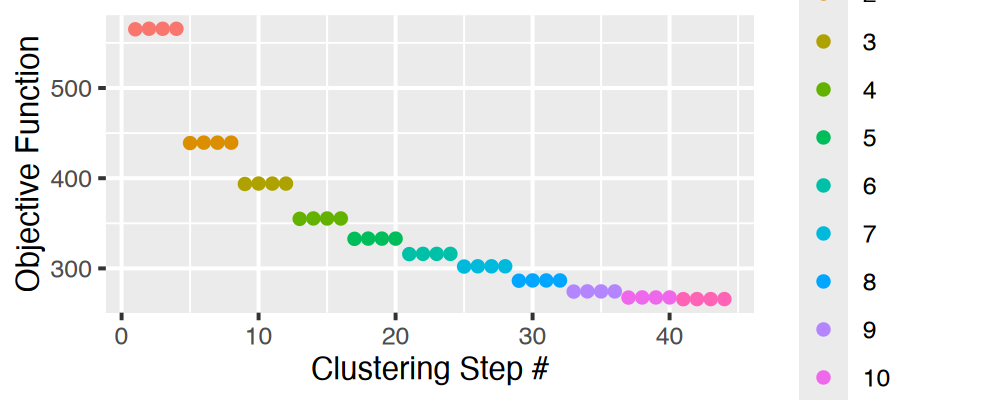

In [9]:
fig.size(2, 5)
set.seed(1)
obj = obj %>% RunHarmony(c("Subject", "dataset", "Run"), theta = c(1, 1, 1), plot_convergence = TRUE, max_iter = 20) %>%
    RunUMAP(reduction = "harmony", dims = 1:30, verbose = .verbose) %>% 
    FindNeighbors(reduction = "harmony", dims = 1:30, verbose = .verbose) %>% 
    FindClusters(resolution = 0.2, verbose = .verbose) %>% 
    identity()

In [10]:
custom.colors.candidate = c('Keratinocyte undiff.'='#3256a8',
                    'Keratinocyte diff.'='#3b9edb',
                    'Fibroblast'='#6533ed',
                    'T cell'='#e39309',
                    'Vascular EC'='#e64a3c',
                    'Macrophage/DC'='#c75656',
                    'Pericyte'='#9698dc',
                    'Hair follicle'='#6da15f',
                    'Melanocyte'='#f283e3',
                    'Lymphatic EC'='#6ef0c9',
                    'Mast'='#dbb81a',
                    'B cell' = '#8cdef5',
                    'Eccrine gland' = 'pink')

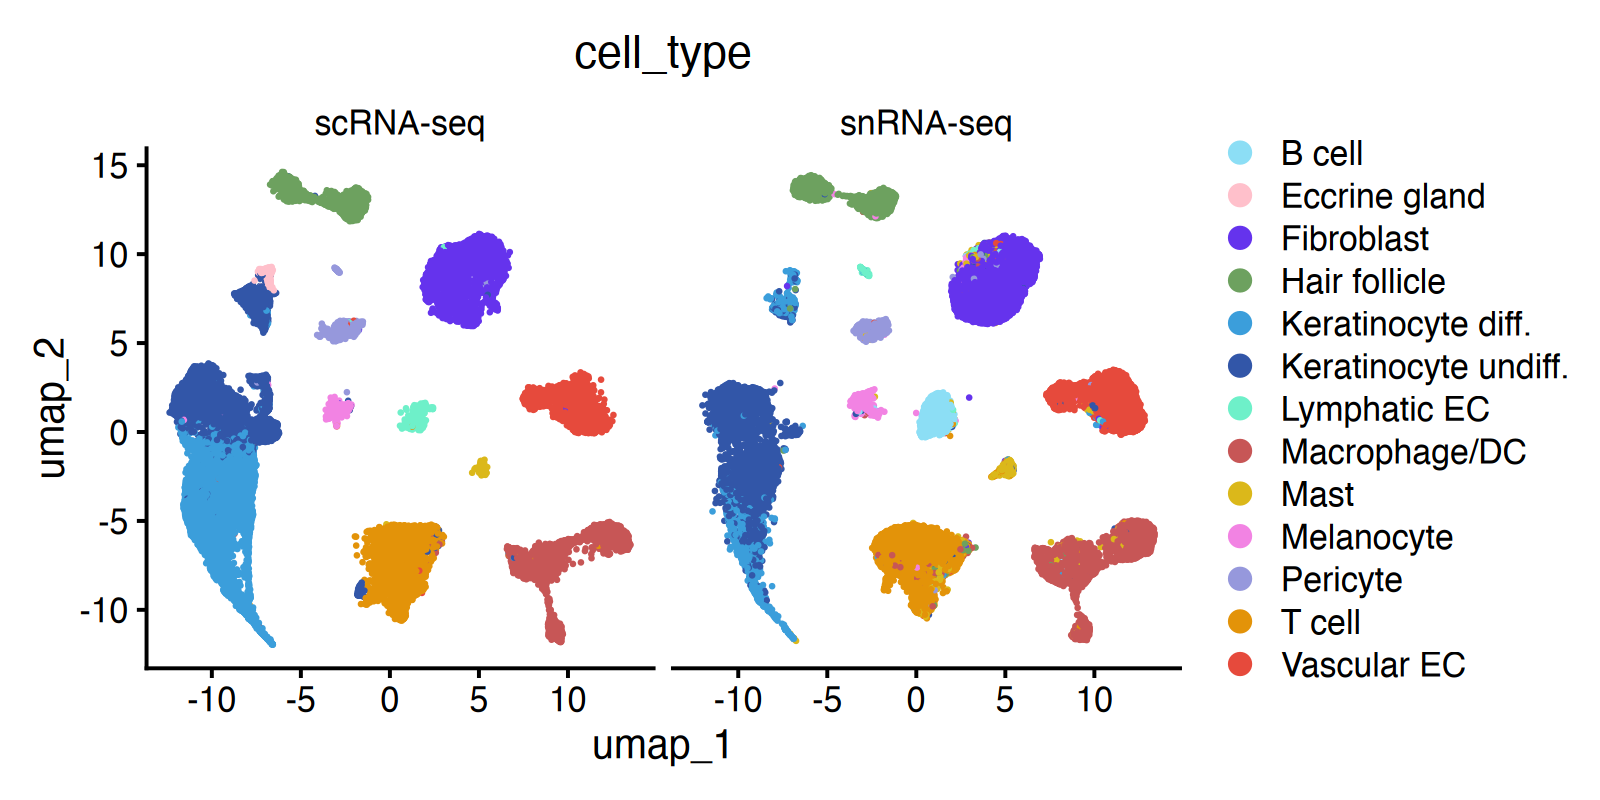

In [11]:
fig.size(4, 8)
DimPlot(obj, reduction = "umap", shuffle = TRUE, group.by = 'cell_type', split.by = 'dataset') + 
    scale_color_manual(values = custom.colors.candidate)

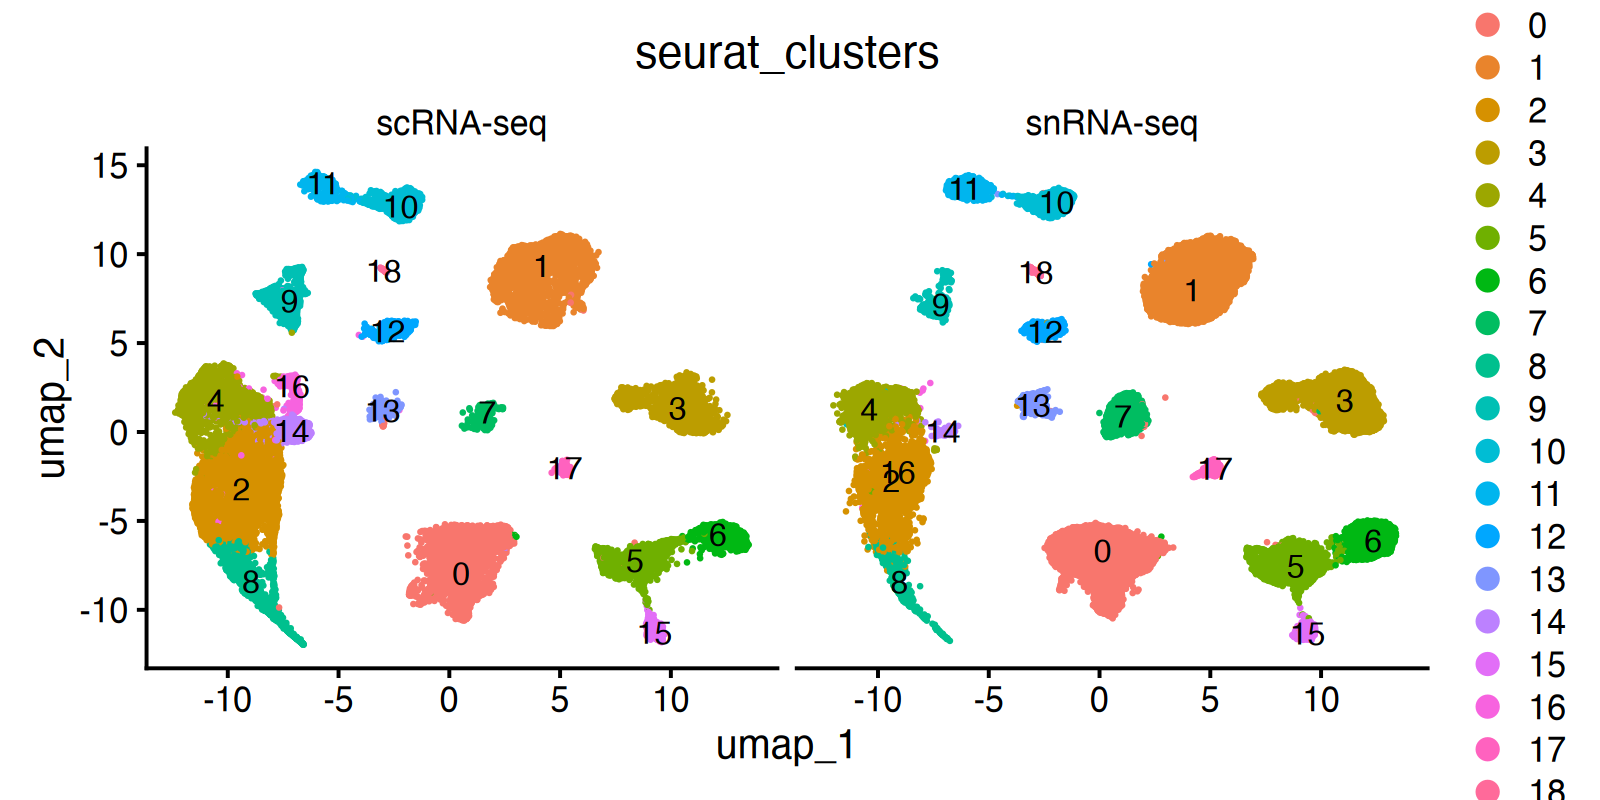

In [12]:
fig.size(4, 8)
DimPlot(obj, reduction = "umap", shuffle = TRUE, group.by = 'seurat_clusters', split.by = 'dataset', label = TRUE)

## Differential expression by cluster

In [13]:
obj_new = JoinLayers(obj)
data.input = GetAssayData(obj_new, assay = "RNA", layer = "data")
obj = obj_new
remove(obj_new)

,feature,group,avgExpr,logFC,statistic,auc,pval,padj,pct_in,pct_out
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,SAMD11,0,0.0007463705,-0.001529977,387127896,0.4994935,1.606468e-03,1.982277e-03,0.02989313,0.1312132
2,NOC2L,0,0.0799848275,-0.060898474,363724688,0.4692974,4.491584e-113,2.267082e-112,3.59464913,9.9687505
3,KLHL17,0,0.0454744324,0.012997665,386685197,0.4989223,1.337821e-01,1.471720e-01,2.09999253,2.3445728
4,PLEKHN1,0,0.0316435401,-0.079838567,363119620,0.4685167,2.274283e-153,1.517330e-152,1.44981690,7.8158181
5,PERM1,0,0.0009512214,-0.002446699,386929472,0.4992375,7.425956e-05,9.625979e-05,0.03736642,0.1899138
6,HES4,0,0.0246533781,-0.137250564,355280266,0.4584020,6.062544e-228,6.244953e-227,1.03878634,9.4110944


0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
ARHGAP15,KAZN,DSP,PECAM1,COL17A1,CD74,F13A1,KALRN,DMKN,KRT14,SLC12A2,DCD,CALD1,DCT,KRT5,CSF2RA,KRT5,HDC,PLIN4
SKAP1,COL1A2,PKP1,MCTP1,KRT14,CIITA,STAB1,ZFPM2,SBSN,TFCP2L1,PLA2R1,KRT7,MYH11,FMN1,KRT14,CD83,TRIM29,GATA2,SORBS1
CHST11,COL6A1,KRT1,VWF,KRT5,CPVL,LGMN,PPFIBP1,CNFN,SEMA3C,ITPR2,COBL,ACTA2,TRPM1,LMNB2,CERS6,CALML3,KIT,FABP4


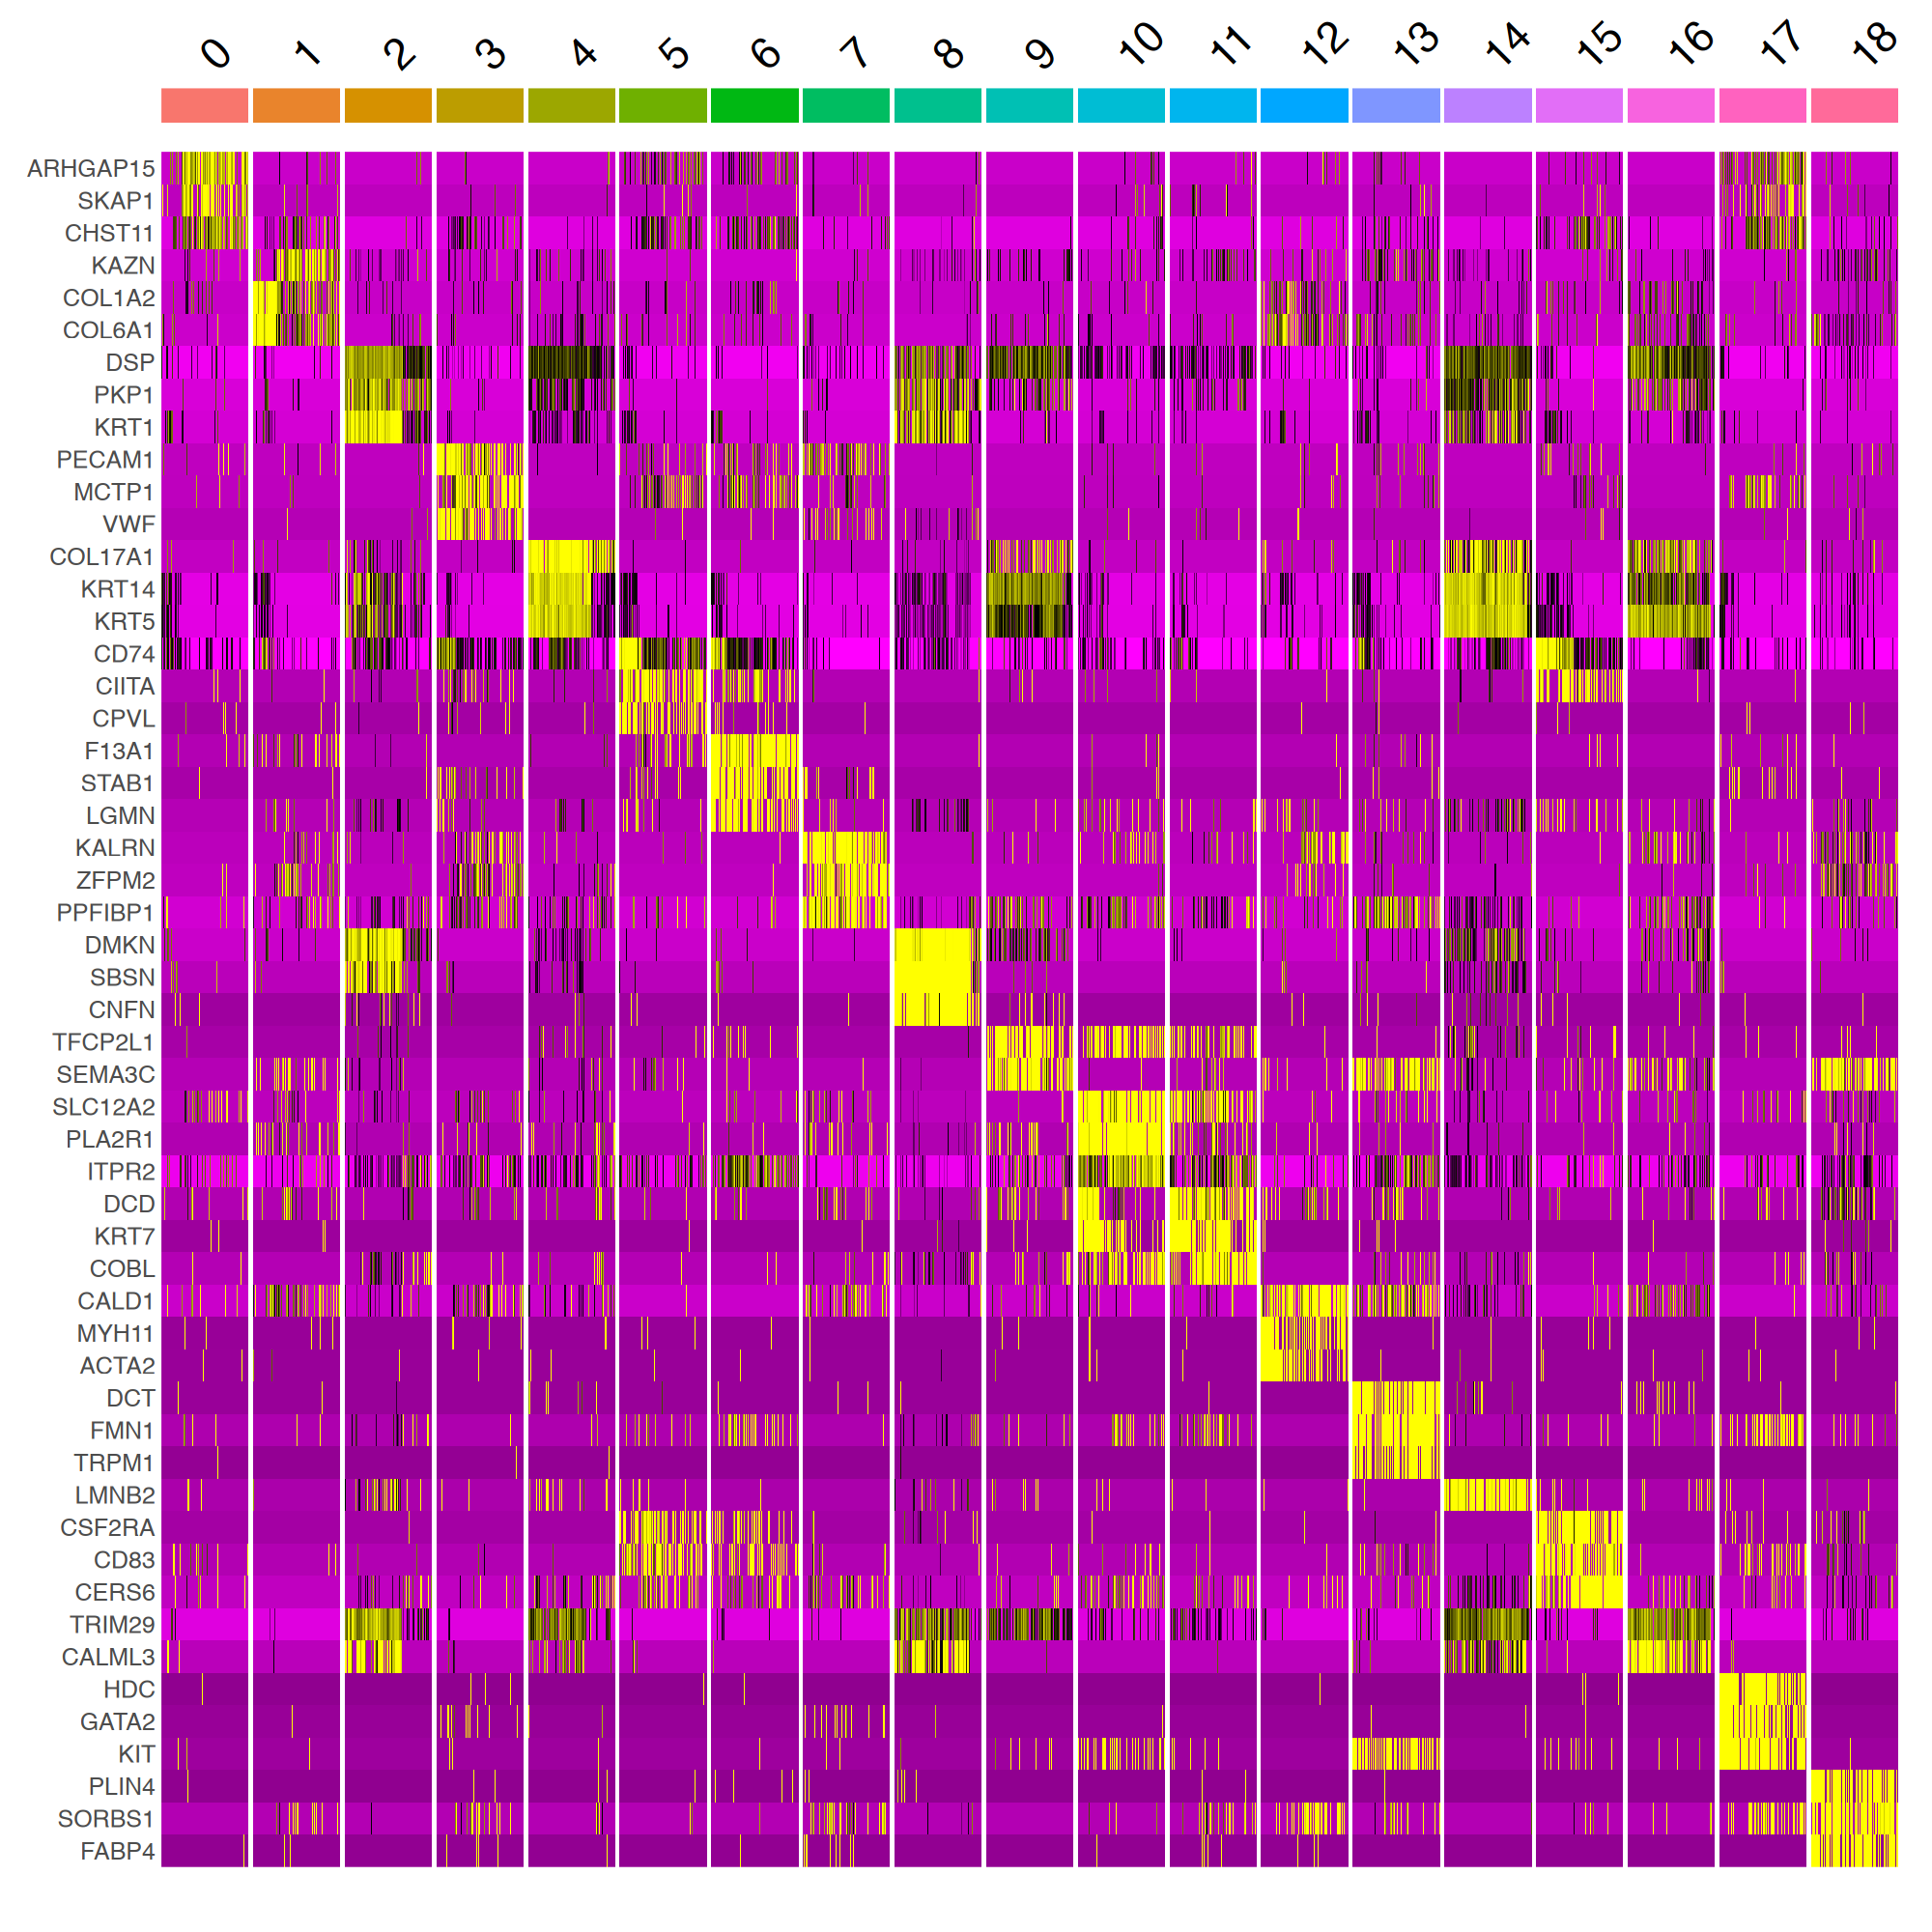

In [14]:
obj_presto = wilcoxauc(obj, 'seurat_clusters')
head(obj_presto)
markers = top_markers(obj_presto, n = 3)
markers = markers[, -1]
markers = markers[, as.character(0:(ncol(markers)-1))]
head(markers)

fig.size(10, 10)
DoHeatmap(subset(obj, downsample = 100), features = unlist(markers)) + NoLegend()

## Plot marker genes

In [15]:
obj_tmp = obj
obj_tmp@meta.data = obj_tmp@meta.data[, 1:14]

obj_tmp = obj_tmp %>% 
              AddModuleScore(features = list(c("KRT5", "KRT14")), name = "Keratinocyte undiff.") %>%
              AddModuleScore(features = list(c("KRT1", "KRT10")), name = "Keratinocyte diff.") %>%
              AddModuleScore(features = list(c("MLANA", "BCAN", "DCT")), name = "Melanocyte") %>%
              AddModuleScore(features = list(c("KRT15", "KRT19")), name = "Hair follicle") %>%
              AddModuleScore(features = list(c("PLIN1", "FABP4", "LPL")), name = "Dermal adipocyte") %>%
              AddModuleScore(features = list(c("PDGFRA", "LUM", "COL6A1", "COL1A2")), name = "Fibroblast") %>%
              AddModuleScore(features = list(c("ACTA2", "MYH11")), name = "Pericyte") %>%
              AddModuleScore(features = list(c("CDH5", "SELE", "SOX17", "VWF")), name = "Vascular EC") %>%
              AddModuleScore(features = list(c("PROX1", "LYVE1")), name = "Lymphatic EC") %>%
              AddModuleScore(features = list(c('KIT', 'MS4A2', "HDC")), name = 'Mast') %>%
              AddModuleScore(features = list(c("LYZ", "AIF1", "CD68", "CD83")), name = "Macrophage/DC") %>%
              AddModuleScore(features = list(c("LCK", "CD3E", "CD3D", "CD3G")), name = "T cell")

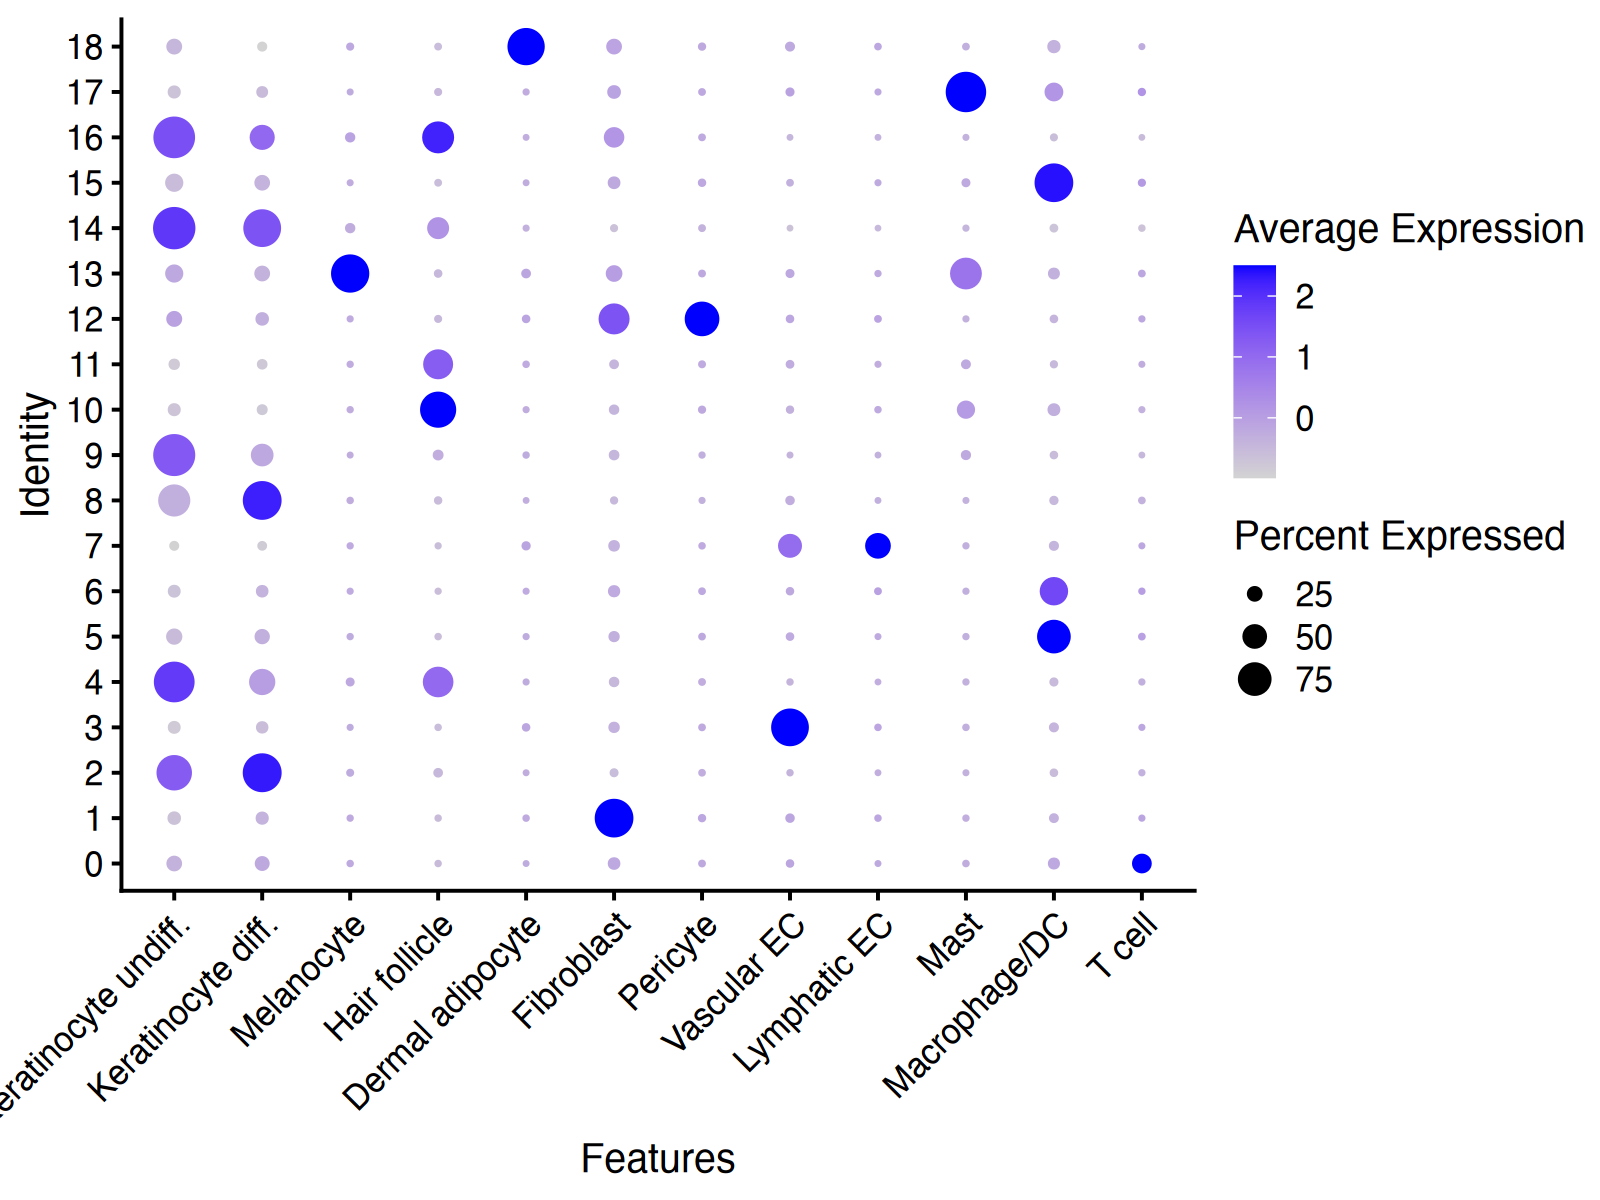

In [16]:
colnames(obj_tmp@meta.data) = sub("1$", "", names(obj_tmp@meta.data))
features = c("Keratinocyte undiff.", "Keratinocyte diff.", "Melanocyte", "Hair follicle", "Dermal adipocyte",
             "Fibroblast", "Pericyte", "Vascular EC", "Lymphatic EC", 'Mast', "Macrophage/DC", "T cell")
fig.size(6, 8)
DotPlot(obj_tmp, features = features) + RotatedAxis()

## Assign cell labels

In [18]:
# Add cluster identities
new.cluster.ids = c("T cell",
                    "Fibroblast", 
                    "Keratinocyte diff.",
                    "Vascular EC",
                    "Keratinocyte undiff.",
                    "Myeloid",
                    "Myeloid",
                    "Lymphatic EC",
                    "Keratinocyte diff.",
                    "Keratinocyte undiff.",
                    "Hair follicle", 
                    "Hair follicle",
                    "Pericyte",
                    "Melanocyte",
                    "Keratinocyte undiff.",
                    "Myeloid",
                    "Keratinocyte undiff.",
                    "Mast",
                    "Dermal adipocyte")
names(new.cluster.ids) = levels(obj)
obj = RenameIdents(obj, new.cluster.ids)
obj@meta.data$cell_type = Idents(obj)

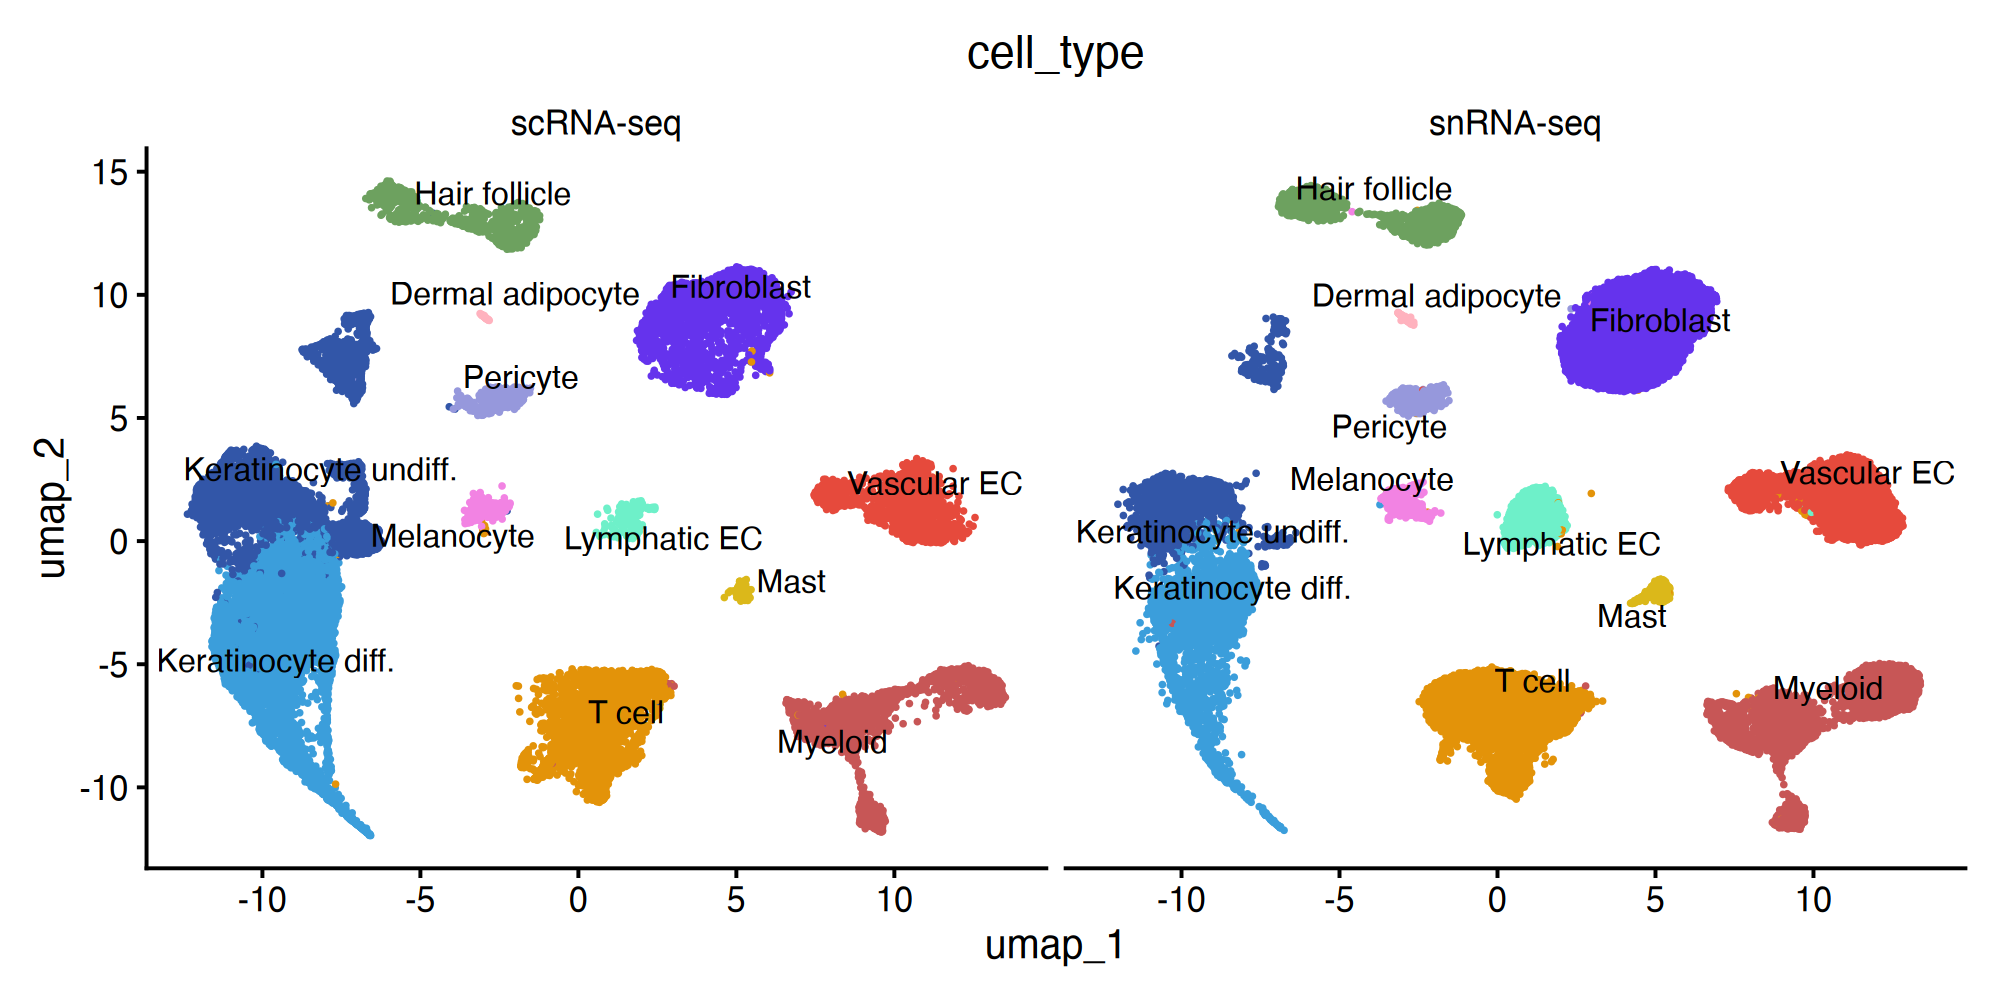

In [19]:
fig.size(5, 10)
DimPlot(obj, reduction = "umap", label = TRUE, pt.size = 0.2, 
        repel = TRUE, shuffle = TRUE, seed = 1, group.by = 'cell_type', split.by = 'dataset') + 
        NoLegend() + scale_color_manual(values = custom.colors)

In [20]:
colnames(obj@meta.data)

[1] "orig.ident"            "nCount_RNA"            "nFeature_RNA"         
 [4] "Cell"                  "Run"                   "Run_ID"               
 [7] "Subject"               "PatientID"             "TimePt"               
[10] "Identity"              "Sample_TimePt"         "dataset"              
[13] "percent.mt"            "scrublet_score"        "RNA_snn_res.0.5"      
[16] "seurat_clusters"       "cell_type"             "souporcell_status"    
[19] "souporcell_assignment" "Type"                  "Condition"            
[22] "RNA_snn_res.0.2"

In [21]:
obj@meta.data$Condition = ifelse(is.na(obj@meta.data$Condition), 
                                 paste0('LesTx_', obj@meta.data$TimePt), obj@meta.data$Condition)

In [22]:
table(obj$dataset)
table(obj$dataset, obj$Condition)


scRNA-seq snRNA-seq 
    27448     43854 

           
            LesTx_Wk0 LesTx_Wk8 LesUntx_Wk0 LesUntx_Wk24 NL_Wk0
  scRNA-seq     17499      9949           0            0      0
  snRNA-seq         0         0       15191        21616   7047

In [23]:
table(obj$cell_type, obj$Condition)

                      
                       LesTx_Wk0 LesTx_Wk8 LesUntx_Wk0 LesUntx_Wk24 NL_Wk0
  T cell                    3020       393        4739         4878    351
  Fibroblast                1642       802        2792         4722   1354
  Keratinocyte diff.        4900      3060        1099         1195    647
  Vascular EC                938       663        1999         3131    949
  Keratinocyte undiff.      4229      3451         606          758   1034
  Myeloid                   1670       416        2185         3161    339
  Lymphatic EC               126        51         589         1164    874
  Hair follicle              299       642         415         1461    692
  Pericyte                   291       295         295          446    184
  Melanocyte                 246       130         278          406    296
  Mast                       131        14         192          210     78
  Dermal adipocyte             7        32           2           84    249

In [24]:
# Save labels and umap coordinates

idx_scRNA = which(obj@meta.data$dataset == 'scRNA-seq')
ct_scRNA = obj@meta.data$cell_type[idx_scRNA]
umap_scRNA = obj@reductions$umap@cell.embeddings[idx_scRNA, c('umap_1', 'umap_2')]
colnames(umap_scRNA) = c('merged_UMAP_1', 'merged_UMAP_2')

idx_snRNA = which(obj@meta.data$dataset == 'snRNA-seq')
umap_snRNA = obj@reductions$umap@cell.embeddings[idx_snRNA, c('umap_1', 'umap_2')]
colnames(umap_snRNA) = c('merged_UMAP_1', 'merged_UMAP_2')

obj_scRNA_labels = obj@meta.data %>% filter(dataset == 'scRNA-seq') %>% dplyr::select(Cell, cell_type) %>% 
    cbind(umap_scRNA)
obj_snRNA_labels = obj@meta.data %>% filter(dataset == 'snRNA-seq') %>% dplyr::select(Cell, cell_type) %>%
    cbind(umap_snRNA)

write.csv(obj_scRNA_labels, '../_data/obj_merged_scRNA_labels.csv', quote = F)
write.csv(obj_snRNA_labels, '../_data/obj_merged_snRNA_labels.csv', quote = F)

In [25]:
# Save Seurat object
saveRDS(obj, '../_data/obj_merged_71302cells_labeled.rds')

In [26]:
max(obj@assays$RNA$data)

[1] 8.854594

# Done!

In [27]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: aarch64-apple-darwin20.0.0
Running under: macOS Sonoma 14.6

Matrix products: default
BLAS/LAPACK: /opt/anaconda3/envs/resiq/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] future_1.70.0               org.Hs.eg.db_3.20.0        
 [3] AnnotationDbi_1.68.0        msigdbr_26.1.0             
 [5] clusterProfiler_4.14.0      rlang_1.2.0                
 [7] scales_1.4.0                patchwork_1.3.2            
 [9] RColorBrewer_1.1-3          rstatix_0.7.3              
[11] mixtools_2.0.0.1            limma_3.62.2               
[13] cowplot_1.2.0               ggrastr_1.0.2              
[15] ggpubr_0.6.3                lme4_2.0-1                 
[17] singlecellmethods_0.1.